In [61]:
# - Pandas
# - Numpy
# - Matplotlib
# - Seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler


# Task 1: Exploring the data (EDA)

Before I explore the data here are some questions I am interested in looking into :

1. How is balance related to age, education and job type?

2. How is outcome related to age, education married and job type?

I will attempt to answer these questions and also glean other information by looking deeper into the data:



In [62]:
# First lets load the data into a dataframe
df = pd.read_csv('./bank.csv')

In [63]:
# Print first 5 rows of the dataframe
df.head(5)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [64]:
# print last 5 rows of the dataframe
df.tail(5)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
1995,20.0,student,single,NaN,no,2785,no,no,cellular,16,sep,327,2,-1,0,NaN,yes
1996,28.0,admin.,single,secondary,no,127,no,no,cellular,16,sep,1334,2,-1,0,NaN,yes
1997,81.0,retired,married,primary,no,1154,no,no,telephone,17,sep,231,1,-1,0,NaN,yes
1998,46.0,services,married,primary,no,4343,yes,no,NaN,20,sep,185,1,-1,0,NaN,yes
1999,40.0,entrepreneur,married,secondary,no,6403,no,no,cellular,22,sep,208,2,-1,0,NaN,yes


In [65]:
# Print statistical summary for all numerical attributes
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,1988.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,41.753018,1413.663500,13.851500,292.020500,1.909500,167.896000,2.561500
std,12.724358,3131.224213,9.712189,221.557295,1.378862,131.754126,3.400735
min,18.000000,-980.000000,1.000000,7.000000,1.000000,-1.000000,0.000000
25%,32.000000,201.500000,5.000000,146.000000,1.000000,75.750000,1.000000
50%,38.000000,551.000000,12.000000,236.000000,1.000000,182.000000,2.000000
75%,50.000000,1644.500000,23.000000,379.000000,2.000000,251.000000,3.000000
max,93.000000,81204.000000,31.000000,1823.000000,11.000000,854.000000,55.000000


In [66]:
# Lets see if there are any missing values
df.isna().sum()

age            12
job            10
marital         0
education     104
default         0
balance         0
housing         0
loan            0
contact       191
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome      454
subscribed      0
dtype: int64

In summary, there are 2000 records containing both numerical and categorical attributes.
There are also a number of categorical and numerical columns that are empty.

I also so noticed that the balance is has a relativly large Std.


Now Let's look at correlattions between numerical data values

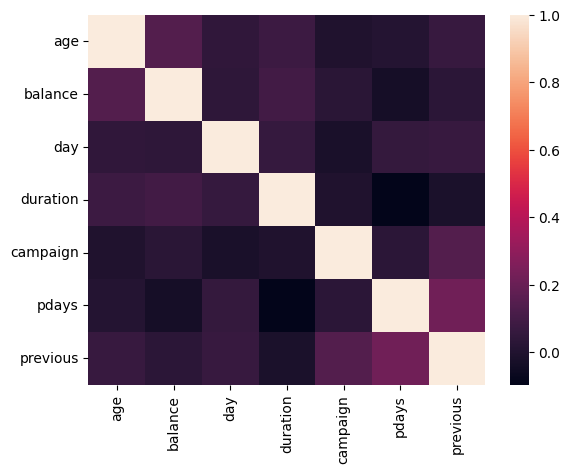

In [67]:
# correlation matrix
df.corr(numeric_only=True)
sns.heatmap(df.corr(numeric_only=True));

There appears to be a greater than 0 correlation between age and balance

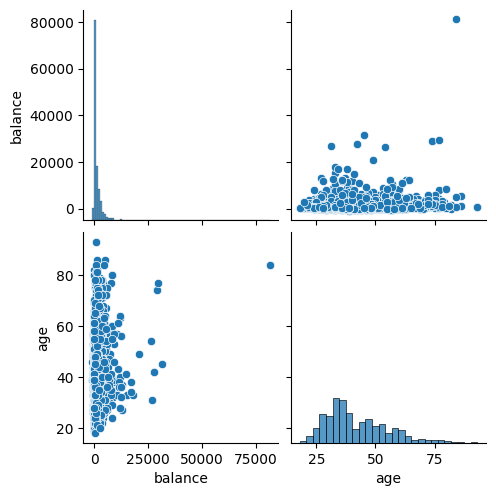

In [68]:
# note that by applying the method dropna() we drop all rows with missing values 
sns.pairplot(data=df[['balance','age']].dropna())
plt.show()

In [69]:
df['job'].value_counts()

job
management       461
technician       348
blue-collar      298
admin.           247
services         165
retired          162
student           96
unemployed        69
self-employed     64
entrepreneur      45
housemaid         35
Name: count, dtype: int64

In [70]:
df['job'].count()

np.int64(1990)

In [71]:
df['marital'].value_counts()

marital
married     1111
single       674
divorced     215
Name: count, dtype: int64

In [72]:
df['marital'].count()

np.int64(2000)

In [73]:
df['education'].value_counts()


education
secondary    995
tertiary     684
primary      217
Name: count, dtype: int64

In [74]:
df['education'].count()

np.int64(1896)

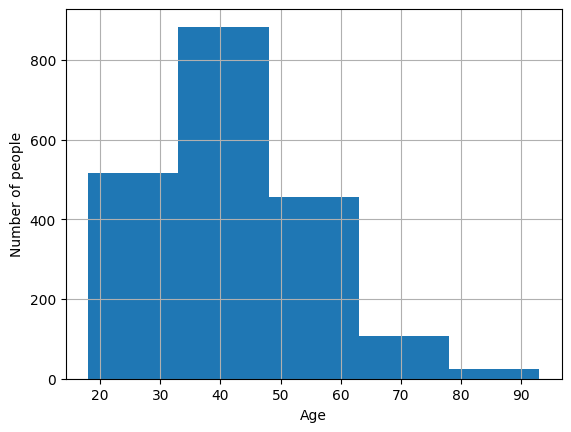

In [75]:
# lets see the distribution of age
df['age'].hist(bins=5)
plt.xlabel('Age')
plt.ylabel('Number of people')
plt.show()

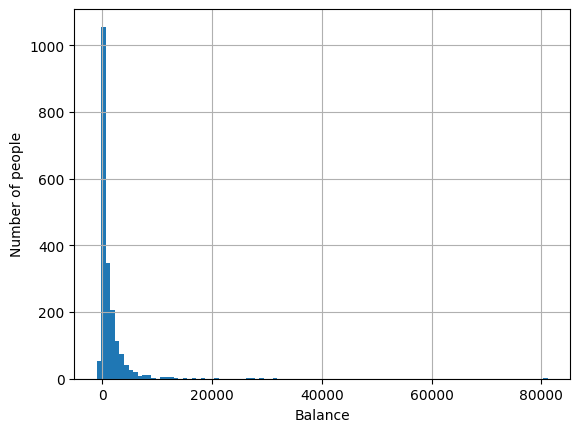

In [76]:
# lets see the distribution of balance
df['balance'].hist(bins=100)
plt.xlabel('Balance')
plt.ylabel('Number of people')
plt.show()

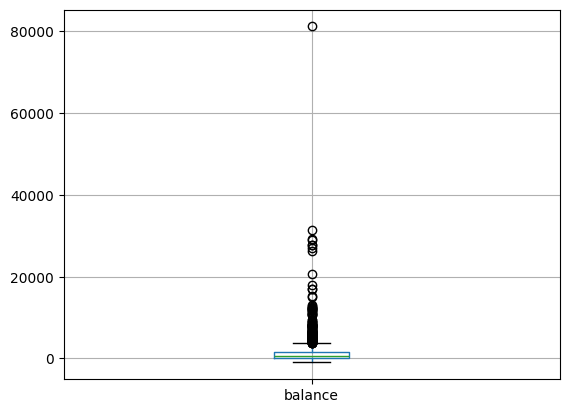

In [77]:
df.boxplot(column='balance')
plt.show()

As can be seen from the boxplot and the distribution above, there are a lot of outliers in the balance. and there is also a lot of variance. Some of this may be due to different age groups, educations and jobs.

Lets break it down by age:


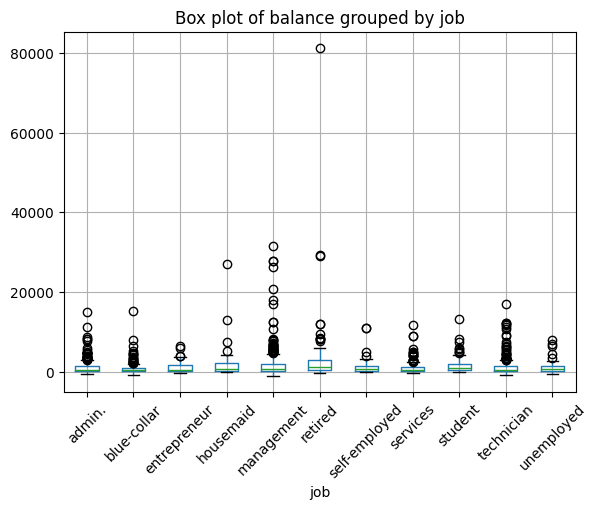

In [78]:
# Box plots of balance, grouped by the categorical attribute age
df.boxplot(column='balance', by='job', rot=45, fontsize=10)
plt.title('Box plot of balance grouped by job')
plt.suptitle("") # get rid of the automatic 'Box plot grouped by group_by_column_name' title
plt.show()


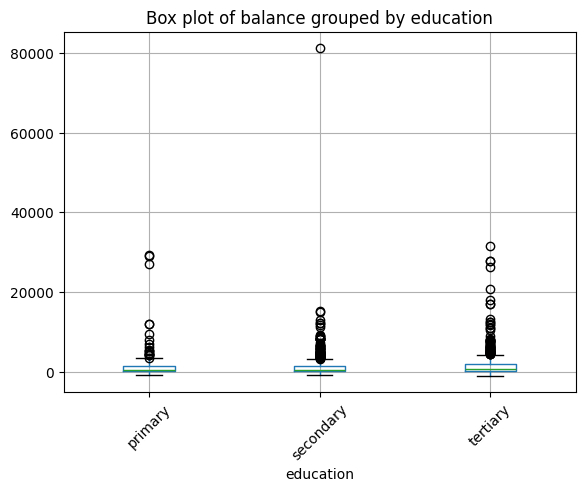

In [79]:
# Box plots of balance, grouped by the categorical attribute age
df.boxplot(column='balance', by='education', rot=45, fontsize=10)
plt.title('Box plot of balance grouped by education')
plt.suptitle("") # get rid of the automatic 'Box plot grouped by group_by_column_name' title
plt.show()


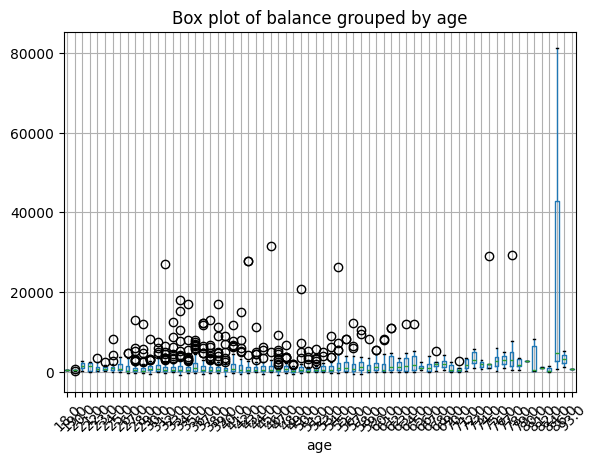

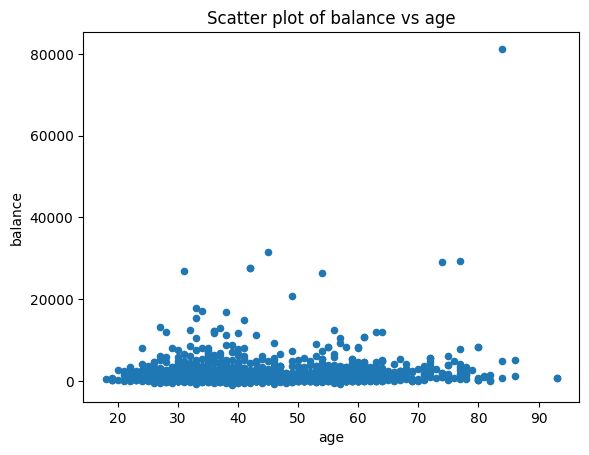

In [80]:
# Box plots of balance, grouped by the categorical attribute age
df.boxplot(column='balance', by='age', rot=45, fontsize=10)
plt.title('Box plot of balance grouped by age')
plt.suptitle("") # get rid of the automatic 'Box plot grouped by group_by_column_name' title
plt.show()


df.plot.scatter(x='age', y='balance')
plt.title('Scatter plot of balance vs age')
plt.show()

# Task 2: Data Preparation

In [81]:
# lets make a copy of the original dataframe as we will be making changes to the original
df_original = df

df.head()


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
0,32.0,technician,single,tertiary,no,392,yes,no,cellular,1,apr,957,2,131,2,failure,no
1,39.0,technician,divorced,secondary,no,688,yes,yes,cellular,1,apr,233,2,133,1,failure,no
2,59.0,retired,married,secondary,no,1035,yes,yes,cellular,1,apr,126,2,239,1,failure,no
3,47.0,blue-collar,married,secondary,no,398,yes,yes,cellular,1,apr,274,1,238,2,failure,no
4,54.0,retired,married,secondary,no,1004,yes,no,cellular,1,apr,479,1,307,1,failure,no


In [82]:
# Lets look at the missing values
df.isna().sum()


age            12
job            10
marital         0
education     104
default         0
balance         0
housing         0
loan            0
contact       191
day             0
month           0
duration        0
campaign        0
pdays           0
previous        0
poutcome      454
subscribed      0
dtype: int64

We can see that there are 5 columns with missing values and that job and education, contact and poutcome are categorical attributes that have missing values, so I will deal with these first. I also note that age has missing values so I will have to deal with that.

In [83]:
# First lets encode the education column as it is an ordinal categorical column

# Create a mapper for the education column

education_mapper = {
    "primary": 0,
    "secondary": 1,
    "tertiary": 2
}

df['education'] = df['education'].replace(education_mapper)

df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,subscribed
1995,20.0,student,single,NaN,no,2785,no,no,cellular,16,sep,327,2,-1,0,NaN,yes
1996,28.0,admin.,single,1,no,127,no,no,cellular,16,sep,1334,2,-1,0,NaN,yes
1997,81.0,retired,married,0,no,1154,no,no,telephone,17,sep,231,1,-1,0,NaN,yes
1998,46.0,services,married,0,no,4343,yes,no,NaN,20,sep,185,1,-1,0,NaN,yes
1999,40.0,entrepreneur,married,1,no,6403,no,no,cellular,22,sep,208,2,-1,0,NaN,yes


In [84]:
# one-hot encode the categorical columns with NaNs
df = pd.get_dummies(df, columns=['job', 'education', 'contact', 'poutcome'], 
                        dummy_na=True, 
                        drop_first=True)
df.tail()


,age,marital,default,balance,housing,loan,day,month,duration,campaign,...,job_unemployed,job_nan,education_1,education_2,education_nan,contact_telephone,contact_nan,poutcome_other,poutcome_success,poutcome_nan
1995,20.0,single,no,2785,no,no,16,sep,327,2,...,False,False,False,False,True,False,False,False,False,True
1996,28.0,single,no,127,no,no,16,sep,1334,2,...,False,False,True,False,False,False,False,False,False,True
1997,81.0,married,no,1154,no,no,17,sep,231,1,...,False,False,False,False,False,True,False,False,False,True
1998,46.0,married,no,4343,yes,no,20,sep,185,1,...,False,False,False,False,False,False,True,False,False,True
1999,40.0,married,no,6403,no,no,22,sep,208,2,...,False,False,True,False,False,False,False,False,False,True


In [85]:
#Next one-hot encode the other categorical columns
df = pd.get_dummies(df, drop_first=True)

df.tail()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,subscribed_yes
1995,20.0,2785,16,327,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1996,28.0,127,16,1334,2,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1997,81.0,1154,17,231,1,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1998,46.0,4343,20,185,1,-1,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1999,40.0,6403,22,208,2,-1,0,False,True,False,...,False,False,False,False,False,False,False,False,True,True


In [86]:
# now lets fill the missing values for age using the median
df['age'] = df['age'].fillna(df['age'].median())

# Lets look at the missing values at this point
df.isna().sum()

age                  0
balance              0
day                  0
duration             0
campaign             0
pdays                0
previous             0
job_blue-collar      0
job_entrepreneur     0
job_housemaid        0
job_management       0
job_retired          0
job_self-employed    0
job_services         0
job_student          0
job_technician       0
job_unemployed       0
job_nan              0
education_1          0
education_2          0
education_nan        0
contact_telephone    0
contact_nan          0
poutcome_other       0
poutcome_success     0
poutcome_nan         0
marital_married      0
marital_single       0
default_yes          0
housing_yes          0
loan_yes             0
month_aug            0
month_dec            0
month_feb            0
month_jan            0
month_jul            0
month_jun            0
month_mar            0
month_may            0
month_nov            0
month_oct            0
month_sep            0
subscribed_yes       0
dtype: int6

Next I will look at rescaling. As noted earlier and as can be observed from the boxplot, the balance attribute has some outliers 

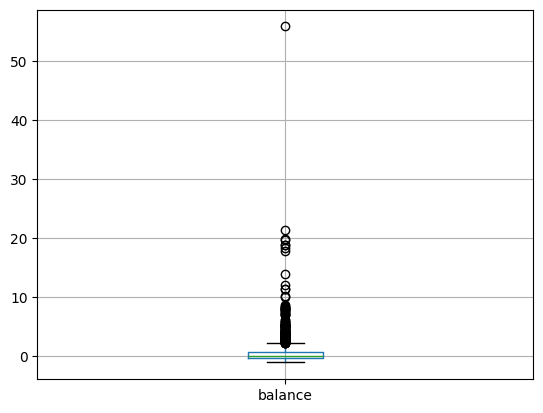

In [90]:
robust_scaler = RobustScaler()
df[['balance']] = robust_scaler.fit_transform(df[['balance']])

df.boxplot(column=['balance'])
plt.show()